# Track Currency SGD/IDR
3 June 2026

## Install Library

In [10]:
# Install gspread untuk export data ke spreadsheet
!pip install gspread gspread_dataframe -q

# Install library yfinance untuk mengambil data finansial langsung dari Yahoo Finance
!pip install yfinance -q

## Import Library

In [11]:
# Import library yang akan digunakan

# yfinance digunakan untuk mengambil data saham, mata uang, komoditas, dan instrumen finansial lainnya
import yfinance as yf

# pandas digunakan untuk mengolah dan menganalisis data tabular
import pandas as pd

# Matplotlib digunakan untuk membuat berbagai jenis chart (seperti line chart, bar chart, pie chart, dan lainnya)
import matplotlib.pyplot as plt

# gspread untuk export data ke spreadsheet
import gspread

from google.auth import default
from gspread_dataframe import set_with_dataframe


## Connect Google Environtment

In [12]:
creds, _ = default()

gc = gspread.authorize(creds)

In [13]:
creds, _ = default()
gc = gspread.authorize(creds)

In [14]:
sheet = gc.open_by_url(
    "https://docs.google.com/spreadsheets/d/1N666zze7Ys56IK8YBcrqdSoWR-rsW7yCMjxZR8nHjQU/edit?gid=452756811"
)

## Download SGD/IDR Data
Documentation: [yfinance - ranaroussi@github](https://ranaroussi.github.io/yfinance/)

In [15]:
# Mengambil data historis nilai tukar SGD terhadap Rupiah selama 5 tahun terakhir dari Yahoo Finance

df = yf.download(
    "SGDIDR=X",   # Ticker SGD terhadap Rupiah
    period="5y",  # Periode data yang ingin diambil
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [16]:
# Menampilkan 5 baris pertama dataset
df.head()

Price,Close,High,Low,Open,Volume
Ticker,SGDIDR=X,SGDIDR=X,SGDIDR=X,SGDIDR=X,SGDIDR=X
Date,,,,,
2021-06-01,10808.056641,10813.064453,10730.348633,10808.260742,0
2021-06-02,10796.915039,10818.169922,10761.224609,10797.160156,0
2021-06-03,10796.915039,10818.169922,10761.224609,10797.160156,0
2021-06-04,10779.038086,10738.669922,10738.669922,10738.669922,0
2021-06-07,10738.669922,10720.570312,10720.570312,10720.570312,0


In [17]:
# Hilangkan level ticker pada kolom
df.columns = df.columns.get_level_values(0)

## Data Preparation

### Reset Index

In [18]:
# Secara default, kolom Date menjadi index

# Reset index digunakan agar Date berubah menjadi kolom biasa sehingga lebih mudah digunakan dalam proses analisis dan visualisasi

df = df.reset_index()

In [19]:
# Melihat hasil perubahan
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2021-06-01,10808.056641,10813.064453,10730.348633,10808.260742,0
1,2021-06-02,10796.915039,10818.169922,10761.224609,10797.160156,0
2,2021-06-03,10796.915039,10818.169922,10761.224609,10797.160156,0
3,2021-06-04,10779.038086,10738.669922,10738.669922,10738.669922,0
4,2021-06-07,10738.669922,10720.570312,10720.570312,10720.570312,0


### Create Date Features

In [20]:
# Membuat beberapa kolom tambahan dari Date agar analisis bulanan dan tahunan menjadi lebih mudah

# Mengambil tahun
df["year"] = df["Date"].dt.year

# Mengambil nomor bulan
df["month"] = df["Date"].dt.month

# Mengambil nama bulan
df["month_name"] = df["Date"].dt.strftime("%B")

# Mengambil kuartal
df["quarter"] = df["Date"].dt.quarter

### Calculate Daily Change

In [21]:
# Menghitung perubahan kurs dibandingkan hari sebelumnya

# Nilai positif menunjukkan SGD menguat
# Nilai negatif menunjukkan SGD melemah

df["Daily_Change"] = df["Close"].diff()

In [22]:
df.head()

Price,Date,Close,High,Low,Open,Volume,year,month,month_name,quarter,Daily_Change
0,2021-06-01,10808.056641,10813.064453,10730.348633,10808.260742,0,2021,6,June,2,NaN
1,2021-06-02,10796.915039,10818.169922,10761.224609,10797.160156,0,2021,6,June,2,-11.141602
2,2021-06-03,10796.915039,10818.169922,10761.224609,10797.160156,0,2021,6,June,2,0.000000
3,2021-06-04,10779.038086,10738.669922,10738.669922,10738.669922,0,2021,6,June,2,-17.876953
4,2021-06-07,10738.669922,10720.570312,10720.570312,10720.570312,0,2021,6,June,2,-40.368164


10796.915039 - 10808.056641 = 11.141602

artinya SGD turun ~11 Rupiah.

### Calculate Moving Average

In [23]:
# Moving Average digunakan untuk melihat tren dan mengurangi fluktuasi harian

# Rata-rata 7 hari terakhir
df["MA_7"] = df["Close"].rolling(7).mean()

# Rata-rata 30 hari terakhir
df["MA_30"] = df["Close"].rolling(30).mean()

In [24]:
# Menampilkan 5 baris terakhir dataset
df.tail()

Price,Date,Close,High,Low,Open,Volume,year,month,month_name,quarter,Daily_Change,MA_7,MA_30
1295,2026-05-26,13903.336914,13983.073242,13874.760742,13896.609375,0,2026,5,May,2,53.057617,13837.607282,13638.155339
1296,2026-05-27,13861.081055,13994.337891,13901.491211,13979.462891,0,2026,5,May,2,-42.255859,13856.700753,13651.069271
1297,2026-05-28,13931.632812,13978.990234,13903.432617,13939.041016,0,2026,5,May,2,70.551758,13869.058175,13665.671615
1298,2026-05-29,13979.274414,14014.296875,13929.086914,13956.972656,0,2026,5,May,2,47.641602,13884.379464,13683.178288
1299,2026-06-01,13993.594727,14012.567383,13990.419922,14005.981445,0,2026,6,June,2,14.320312,13909.422154,13701.157650


Moving Average menghitung rata-rata beberapa hari terakhir.

Kurs SGD/IDR 7 hari terakhir
12,100
12,130
12,090
12,150
12,120
12,180

---

Misal MA 7,
(12100 + 12130 + 12090 + 12150 + 12120 + 12180 + 12200) / 7 = 12138.57142857143

## Data Visualization

### Generate KPI Metrics

In [25]:
# Mengambil nilai kurs terbaru
current_rate = df["Close"].iloc[-1]

# Mengambil kurs tertinggi
highest_idx = df["Close"].idxmax()
highest_rate = df.loc[highest_idx, "Close"]
highest_date = df.loc[highest_idx, "Date"]

# Mengambil kurs terendah
lowest_idx = df["Close"].idxmin()
lowest_rate = df.loc[lowest_idx, "Close"]
lowest_date = df.loc[lowest_idx, "Date"]

# Menghitung rata-rata kurs
average_rate = df["Close"].mean()

In [26]:
# Menampilkan hasil
print(f"Current SGD/IDR : {current_rate:,.2f}")

print(
    f"Highest SGD/IDR : {highest_rate:,.2f} "
    f"({highest_date.strftime('%d %b %Y')})"
)

print(
    f"Lowest SGD/IDR  : {lowest_rate:,.2f} "
    f"({lowest_date.strftime('%d %b %Y')})"
)

print(f"Average SGD/IDR : {average_rate:,.2f}")

Current SGD/IDR : 13,993.59
Highest SGD/IDR : 13,993.59 (01 Jun 2026)
Lowest SGD/IDR  : 10,416.39 (27 Dec 2021)
Average SGD/IDR : 11,658.27


### Historical SGD Trend

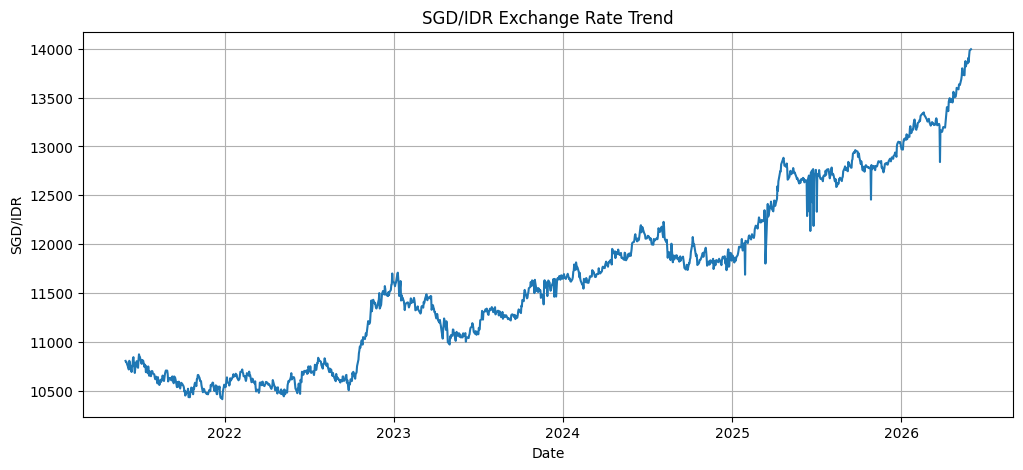

In [27]:
# Menentukan ukuran chart
plt.figure(figsize=(12,5))

# Memilih plot
plt.plot(
    df["Date"], #variabel X
    df["Close"] #variabel Y
)

# Menambahkan judul chart
plt.title("SGD/IDR Exchange Rate Trend")

# Menambahkan label chart
plt.xlabel("Date")
plt.ylabel("SGD/IDR")

# Menambahkan grid
plt.grid(True)

# Menampilkan chart
plt.show()

### SGD vs Moving Average

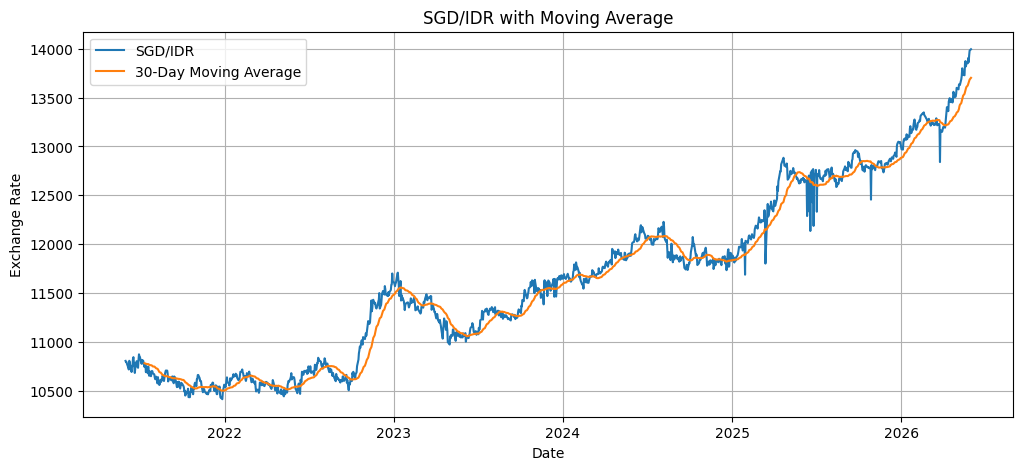

In [28]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Close"],
    label="SGD/IDR" # Menambahkan label untuk line 1
)

plt.plot(
    df["Date"],
    df["MA_30"],
    label="30-Day Moving Average" # Menambahkan label untuk line 2
)

plt.title("SGD/IDR with Moving Average")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

# Menambahkan legend, untuk plot dengan memberi label pada berbagai elemen pada grafik
plt.legend()

plt.grid(True)

plt.show()

### Average SGD per Year

In [29]:
yearly_avg = (
    df.groupby("year")["Close"]
      .mean()
      .reset_index()
)

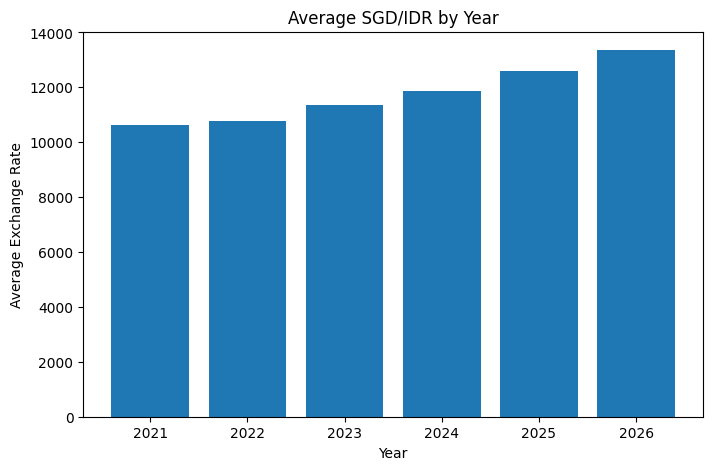

In [30]:
plt.figure(figsize=(8,5))

plt.bar(
    yearly_avg["year"],
    yearly_avg["Close"]
)

plt.title("Average SGD/IDR by Year")
plt.xlabel("Year")
plt.ylabel("Average Exchange Rate")

plt.show()

## Export data to Spreadsheet

In [32]:
# Menyimpan ke dalam sheet pada spreadsheet

worksheet = sheet.worksheet("currency_sgd_to_idr")

worksheet.clear()

set_with_dataframe(
    worksheet,
    df
)